# 03 — The Need for Adaptation: AdEx

**Goal of this notebook.** Neither LIF nor EIF can do something real cortical neurons do constantly: **change their firing rate over the course of a single, constant-current step.** A regular-spiking cortical neuron driven by a steady current fires quickly at first and then slows down — *spike-frequency adaptation (SFA)*. Some neurons instead fire in tight clusters separated by silence — *bursting*. Neither behavior is possible in a model whose only state variable is $v$: the sub-threshold dynamics reset to an identical state after every spike, so every inter-spike interval under constant input would have to look the same.

The **Adaptive Exponential Integrate-and-Fire (AdEx)** model fixes this with a second state variable, $w$ — a slow current that builds up with spiking and feeds back onto $v$:

$$C_m \frac{dv}{dt} = -g_L(v - E_L) + g_L \Delta_T \exp\!\left(\frac{v - v_T}{\Delta_T}\right) - w + I(t)$$

$$\tau_w \frac{dw}{dt} = a(v - E_L) - w + b\,\tau_w \sum_f \delta(t - t^f)$$

The $b\,\tau_w \sum_f \delta(t-t^f)$ term means exactly what it looks like: **every spike instantaneously jumps $w$ up by $b$** (that's what integrating a $\delta$-function against $\tau_w\,dw/dt$ gives you); between spikes, $w$ just decays with time constant $\tau_w$ back toward $a(v-E_L)$. `AdExNeuron.apply_reset` implements this exactly — `state[1] += self.b` at every spike, nothing smoothed or approximated.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.neuron_models import LIFNeuron, AdExNeuron

%matplotlib inline

mpl.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

COLOR_V = "#2b6cb0"
COLOR_W = "#dd6b20"
COLOR_LIF = "#a0aec0"


## 1. Watching adaptation happen

A single AdEx neuron, constant supra-threshold current, $a=0$ (no *subthreshold* coupling — $w$ only responds to spikes) and $b=60$ pA (a substantial *spike-triggered* jump). Watch $v$ and $w$ together.

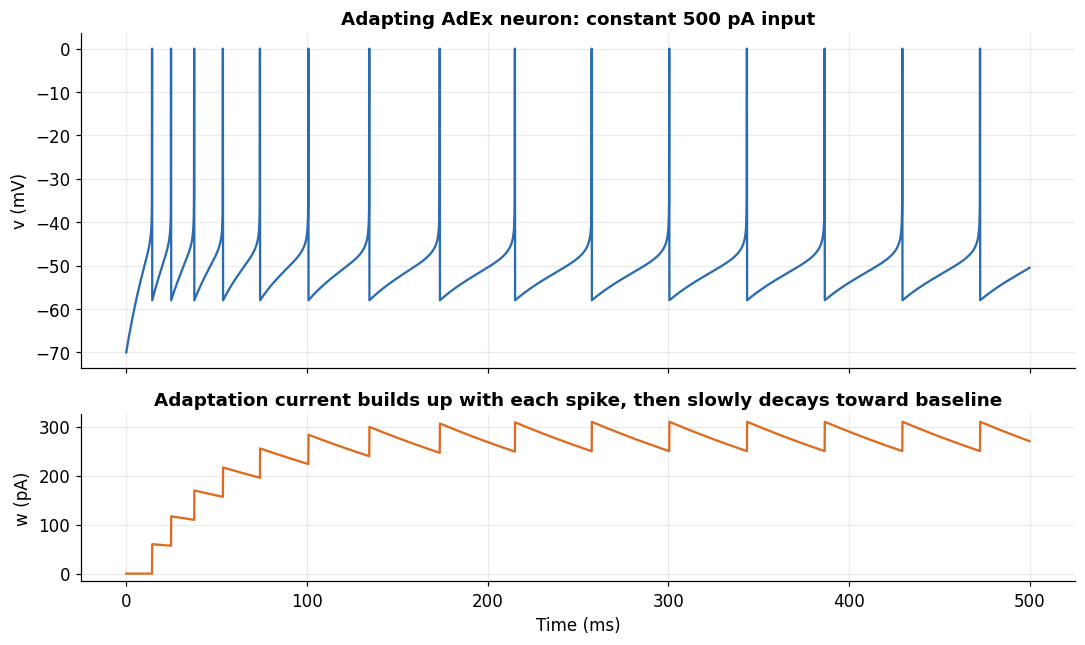

15 spikes. First 3 ISIs: [10.5 12.8 15.9] ms. Last 3 ISIs: [43. 43. 43.] ms.
Notice each spike produces a visible step increase in w, and ISIs visibly lengthen as w accumulates.


In [2]:
adex = AdExNeuron(C_m=200.0, g_L=10.0, E_L=-70.0, v_T=-50.0, delta_T=2.0,
                   a=0.0, b=60.0, tau_w=200.0, v_reset=-58.0, dt=0.1)
res = adex.simulate(I_ext=500.0, T=500.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(res["t"], res["v"], color=COLOR_V)
ax1.set_ylabel("v (mV)")
ax1.set_title("Adapting AdEx neuron: constant 500 pA input")

ax2.plot(res["t"], res["w"], color=COLOR_W)
ax2.set_ylabel("w (pA)")
ax2.set_xlabel("Time (ms)")
ax2.set_title("Adaptation current builds up with each spike, then slowly decays toward baseline")
plt.tight_layout()
plt.show()

isis = np.diff(res["spike_times"])
print(f"{len(res['spike_times'])} spikes. First 3 ISIs: {np.round(isis[:3],1)} ms. Last 3 ISIs: {np.round(isis[-3:],1)} ms.")
print("Notice each spike produces a visible step increase in w, and ISIs visibly lengthen as w accumulates.")


## 2. Spike-frequency adaptation, directly visualized: LIF vs. AdEx

The cleanest way to *show* SFA is to plot the inter-spike interval against spike number within a single trial. A model with no adaptation mechanism (LIF) gives a flat line — every ISI is identical. AdEx gives a rising curve.

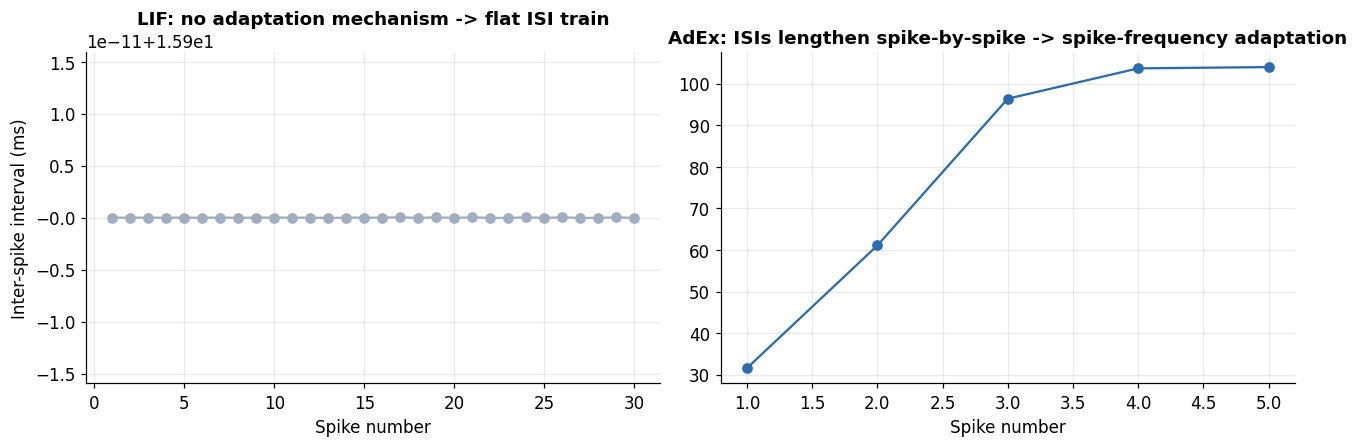

In [3]:
lif = LIFNeuron()
res_lif = lif.simulate(I_ext=300.0, T=500.0)
isis_lif = np.diff(res_lif["spike_times"])

adex.reset_state()
res_adex = adex.simulate(I_ext=300.0, T=500.0)
isis_adex = np.diff(res_adex["spike_times"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
axes[0].plot(np.arange(1, len(isis_lif) + 1), isis_lif, "o-", color=COLOR_LIF)
axes[0].set_title("LIF: no adaptation mechanism -> flat ISI train")
axes[0].set_xlabel("Spike number"); axes[0].set_ylabel("Inter-spike interval (ms)")

axes[1].plot(np.arange(1, len(isis_adex) + 1), isis_adex, "o-", color=COLOR_V)
axes[1].set_title("AdEx: ISIs lengthen spike-by-spike -> spike-frequency adaptation")
axes[1].set_xlabel("Spike number")
plt.tight_layout()
plt.show()


## 3. F-I curves: instantaneous vs. steady-state rate

Because AdEx's firing rate *changes during the trial*, a single F-I curve is no longer the whole story — we need two: the **instantaneous** rate from the very first ISI (before adaptation has built up), and the **steady-state** rate from the last few ISIs (after $w$ has equilibrated). The gap between them, as a function of current, *is* the adaptation.

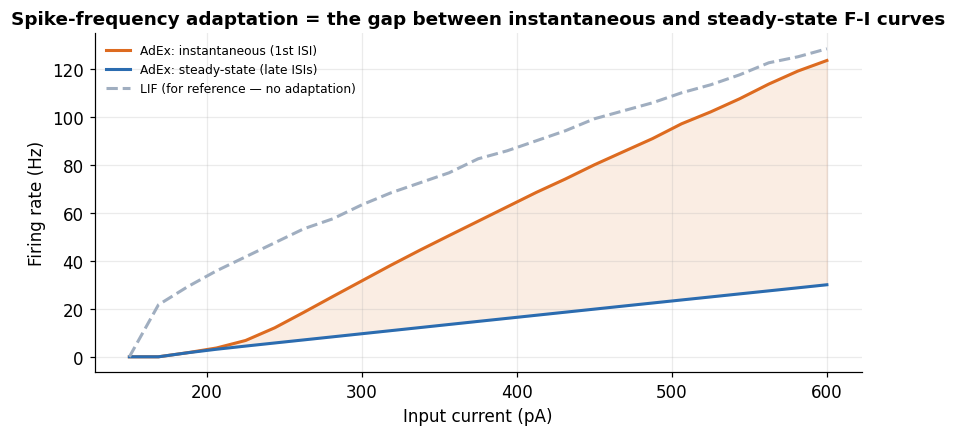

In [4]:
def instantaneous_and_steady_rate(neuron, I, T=1500.0, transient_fraction=0.6):
    neuron.reset_state()
    res = neuron.simulate(I_ext=I, T=T)
    spikes = res["spike_times"]
    if len(spikes) < 2:
        return 0.0, 0.0
    isis = np.diff(spikes)
    inst_rate = 1000.0 / isis[0]
    steady_isis = isis[spikes[1:] >= transient_fraction * T]
    steady_rate = 1000.0 / np.mean(steady_isis) if len(steady_isis) > 0 else inst_rate
    return inst_rate, steady_rate


I_values = np.linspace(150, 600, 25)
inst_rates, steady_rates = [], []
for I in I_values:
    adex.reset_state()
    i_r, s_r = instantaneous_and_steady_rate(adex, I)
    inst_rates.append(i_r); steady_rates.append(s_r)

lif_rates = lif.f_i_curve(I_values, T=1500.0, transient=300.0)

fig, ax = plt.subplots()
ax.plot(I_values, inst_rates, color=COLOR_W, lw=2, label="AdEx: instantaneous (1st ISI)")
ax.plot(I_values, steady_rates, color=COLOR_V, lw=2, label="AdEx: steady-state (late ISIs)")
ax.plot(I_values, lif_rates, color=COLOR_LIF, lw=2, ls="--", label="LIF (for reference — no adaptation)")
ax.fill_between(I_values, inst_rates, steady_rates, color=COLOR_W, alpha=0.12)
ax.set_xlabel("Input current (pA)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("Spike-frequency adaptation = the gap between instantaneous and steady-state F-I curves")
ax.legend(fontsize=8)
plt.show()


The shaded gap is entirely due to $w$: AdEx starts firing at a rate close to what a similarly-parameterized LIF neuron would, then relaxes down onto its own, lower, steady-state curve as adaptation kicks in.

## 4. A gallery of firing patterns

The remarkable thing about AdEx is how much qualitative behavior these two extra parameters, $a$ and $b$ (plus $\tau_w$ and $v_{reset}$), unlock — from perfectly regular tonic spiking to genuine bursting — all from the *same* two-equation model, just retuned. All four traces below use an identical 500 pA step current; only $(a, b, \tau_w, v_{reset})$ change.

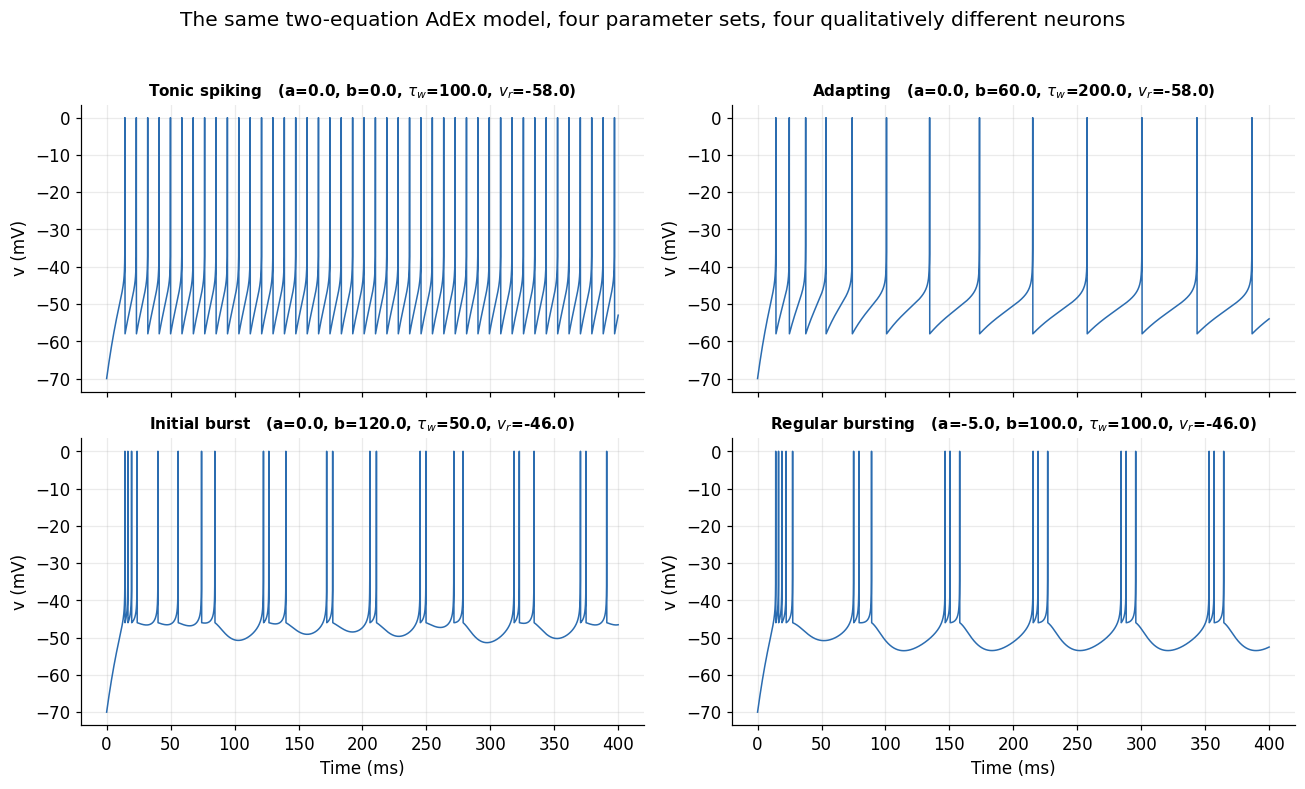

In [5]:
regimes = {
    "Tonic spiking":    dict(a=0.0,  b=0.0,   tau_w=100.0, v_reset=-58.0),
    "Adapting":         dict(a=0.0,  b=60.0,  tau_w=200.0, v_reset=-58.0),
    "Initial burst":    dict(a=0.0,  b=120.0, tau_w=50.0,  v_reset=-46.0),
    "Regular bursting": dict(a=-5.0, b=100.0, tau_w=100.0, v_reset=-46.0),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (name, params) in zip(axes.flat, regimes.items()):
    n = AdExNeuron(C_m=200.0, g_L=10.0, E_L=-70.0, v_T=-50.0, delta_T=2.0, v_peak=0.0, dt=0.1, **params)
    res = n.simulate(I_ext=500.0, T=400.0)
    ax.plot(res["t"], res["v"], color=COLOR_V, lw=1)
    ax.set_title(f"{name}   (a={params['a']}, b={params['b']}, "
                 f"$\\tau_w$={params['tau_w']}, $v_r$={params['v_reset']})", fontsize=10)
    ax.set_ylabel("v (mV)")
for ax in axes[-1, :]:
    ax.set_xlabel("Time (ms)")
fig.suptitle("The same two-equation AdEx model, four parameter sets, four qualitatively different neurons", y=1.02)
plt.tight_layout()
plt.show()


- **Tonic spiking** ($b=0$): with no spike-triggered adaptation at all, this is just EIF again — perfectly regular firing.
- **Adapting**: spike-triggered $w$ jumps ($b=60$) with a slow decay ($\tau_w=200$ms) progressively lengthen every ISI.
- **Initial burst**: a large $b$ and a *fast* $\tau_w$ combine with a reset voltage close to $v_T$ — a few rapid spikes escape before $w$ has time to build up and shut things down, then the neuron settles into slow, adapted firing.
- **Regular bursting**: a *negative* $a$ (subthreshold facilitation, rather than the usual damping) together with a high reset voltage lets the neuron periodically escape adaptation's grip and burst again — clusters of spikes separated by silence, repeating.

*Why* these particular combinations of $a$, $b$, and $v_{reset}$ produce tonic vs. bursting behavior is a question about the geometry of the $(v, w)$ phase plane — which is exactly what Notebook 04 digs into, interactively.

## Summary

- AdEx adds one state variable, $w$, whose only jobs are: decay toward $a(v-E_L)$ between spikes, and jump by $b$ at every spike.
- That's enough to reproduce spike-frequency adaptation (lengthening ISIs under constant current) — directly visible as the gap between AdEx's instantaneous and steady-state F-I curves, which LIF simply doesn't have.
- Retuning just $(a, b, \tau_w, v_{reset})$ — no other change to the model — reproduces tonic spiking, adaptation, initial bursting, and regular bursting.

**Next:** [04 — Phase Plane Analysis](04_Phase_Plane_Analysis.ipynb) makes the mechanism behind these regimes interactive: drag $a$ and $b$ yourself and watch the nullclines (and the firing pattern) shift in real time.
